In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.append('src')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

from kalman_tracker import KalmanFilter
from state_logger import StateLogger
from gps_stats import GPSStats

# Kalman Filter for GPS Trajectory Smoothing: Theory and Experiment

**Description:** In this notebook, "Kalman Filter for GPS Trajectory Smoothing: Theory and Experiment", we build a linear Kalman filter from first principles and apply it to real GPS trajectories from the Microsoft GeoLife dataset. We introduce two motion models — Constant Velocity (CV) and Constant Acceleration (CA) — derive the corresponding state transition and noise covariance matrices, and embed them into a generic Kalman filter implementation. The filter is applied to labelled car and taxi segments, evaluated with acceleration RMS and innovation analysis, and compared across models. The outcome is a working GPS smoothing pipeline, tested on 2 real urban trajectories — the longest valid car and taxi segments found across 111 labelled intervals in the dataset.

**What this notebook covers:**

1. **Introduction**
2. **Theory and Motion Model** — motion models, predict/update cycle, noise covariances $Q$ and $R$.
3. **Dataset** — Microsoft GeoLife GPS: car and taxi segments, ~1 s sampling.
4. **Realization** — CV vs CA on 2 labelled segments; metrics: acceleration RMS, innovation analysis.
5. **Summary**

## Introduction

The Kalman filter is a recursive algorithm for estimating the state of a dynamic system from a sequence of noisy observations. At each time step, it alternates between two operations: a **prediction** — where the next state is forecasted from a motion model — and an **update** — where that forecast is corrected using a new sensor measurement. The balance between the two is governed by the *Kalman gain*, which weighs model confidence against measurement reliability automatically.

**Motivation — GPS noise.** Raw GPS fixes carry positional noise that makes trajectories jagged, and velocity estimates unreliable. A Kalman filter recovers a smooth, physically consistent trajectory without discarding observations or tuning a window size.

We consider two motion models applied to the same GPS data:

- **CV** — $\mathbf{s}_k = [x,\; y,\; v_x,\; v_y]^\top$ — constant velocity;
- **CA** — $\mathbf{s}_k = [x,\; y,\; v_x,\; v_y,\; a_x,\; a_y]^\top$ — constant acceleration.

In both cases the sensor measures only position $\mathbf{z}_k = [x,\; y]^\top \in \mathbb{R}^2$. The key question is whether the more complex model actually performs better on real data — **model complexity should be justified by data, not assumed.**

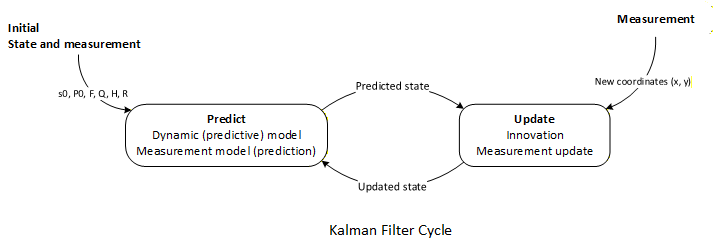

## Theory and Motion Model

We have a vehicle moving through Beijing. A GPS receiver reports its position every second — but each fix carries an error. We cannot trust any single reading, but we can do better by combining two sources of information:

1. **What the physics tells us** — if we know where the vehicle was and how fast it was moving, we can predict where it should be now. This is the motion model, encoded in $F$.

2. **What the GPS reports** — a noisy but direct observation of position, encoded in $z_k$.

The Kalman filter blends these two sources optimally at every step. How much to trust each one depends on two things: how uncertain we are about the motion model ($Q$, $P$) and how noisy the GPS is ($R$). The result is a smooth, physically consistent trajectory where position, velocity and acceleration are all estimated together — even though the GPS reports only position.

The following sections derive each component of this framework formally.

#### State vector

The state vector $s_k$ describes the kinematic state of the tracked object at time step $k$. Each component has a direct physical meaning:

- $x, y$ — position in the local Cartesian plane (metres)
- $v_x, v_y$ — velocity components (metres per second)
- $a_x, a_y$ — acceleration components (metres per second squared)

We consider two models depending on which components are included:

$$
\text{CV:} \quad s_k = [x,\; y,\; v_x,\; v_y]^\top \in \mathbb{R}^4
$$
$$
\text{CA:} \quad s_k = [x,\; y,\; v_x,\; v_y,\; a_x,\; a_y]^\top \in \mathbb{R}^6
$$

The GPS receiver observes only position — $v_x, v_y$ and $a_x, a_y$ are hidden states estimated by the filter.

#### State transition matrix

Using classical kinematics for a small step $dt$ [KalmanFilterNet], [WelchBishop]:

$$
x_{k+1} = x_k + v_{x,k}\,dt + \tfrac{1}{2}a_{x,k}\,dt^2, \qquad
v_{x,k+1} = v_{x,k} + a_{x,k}\,dt
$$

and analogously for $y$. In the CV model, $a_{x,k} = a_{y,k} = 0$.

Both models share the same structure [WikipediaKF], [WelchBishop]:

$$
s_{k+1} = F(dt)\, s_k + B\,u_k + w_k, \qquad F(dt) \in \mathbb{R}^{n \times n}
$$

where $w_k$ models unknown disturbances and $B\,u_k$ is an optional control input. There is no control input in our GPS application — the vehicle is passively observed, so $B = \mathbf{0}$ [KalmanFilterNet, Example 9].

The matrix $F(dt)$ is built directly from the kinematic equations above and is rebuilt at each step since GPS sampling is irregular. 
For the CV model ($n=4$):

$$
F_{CV}(dt) = \begin{bmatrix}
1 & 0 & dt & 0 \\
0 & 1 & 0  & dt \\
0 & 0 & 1  & 0 \\
0 & 0 & 0  & 1
\end{bmatrix}
$$

For the CA model ($n=6$):

$$
F_{CA}(dt) = \begin{bmatrix}
1 & 0 & dt & 0  & \tfrac{1}{2}dt^2 & 0 \\
0 & 1 & 0  & dt & 0 & \tfrac{1}{2}dt^2 \\
0 & 0 & 1  & 0  & dt & 0 \\
0 & 0 & 0  & 1  & 0  & dt \\
0 & 0 & 0  & 0  & 1  & 0 \\
0 & 0 & 0  & 0  & 0  & 1
\end{bmatrix}
$$

#### Process noise Q

Real motion is never perfectly constant — a vehicle accelerates, brakes, and turns. These unpredictable deviations are modelled as process noise $w_k$ [WelchBishop], [KalmanFilterNet]:

$$
\mathbb{E}[w_k] = 0, \qquad \mathbb{E}[w_k w_k^\top] = Q.
$$

We assume noise acts only on acceleration — position and velocity inherit uncertainty through $F$ [KalmanFilterNet]:

$$
Q_a^{CA} = \sigma_a^2\,\operatorname{diag}(0,0,0,0,1,1), \qquad
Q_a^{CV} = \sigma_a^2\,\operatorname{diag}(0,0,1,1), \qquad
Q = F\,Q_a\,F^\top
$$

The single parameter $\sigma_a^2$ controls the trade-off:

- **small** $\sigma_a^2$ — trust the motion model; smooth trajectory
- **large** $\sigma_a^2$ — allow erratic motion; trajectory follows measurements

#### Measurement model

The matrix $H \in \mathbb{R}^{2 \times n}$ is the bridge between the full state and what the sensor actually sees. The filter maintains a rich internal state $s_k$ with position, velocity and acceleration — but the GPS reports only position. $H$ projects the state down to measurement space so that the filter can compare its prediction with the incoming GPS fix.

$$
H = \begin{bmatrix} 1 & 0 & \cdots & 0 \\ 0 & 1 & \cdots & 0 \end{bmatrix}
$$

The measurement noise covariance $R$ indicates how much the filter should trust each GPS fix. A large $R$ indicates that the sensor is noisy; the filter relies more on its motion model. A small $R$ means the GPS is accurate — the filter follows the measurements closely:

$$
R = \sigma_r^2\, I_2
$$

In practice, $\sigma_r$ is typically obtained from the GPS receiver specification. In this analysis, $\sigma_r \approx 7.5$ m is estimated empirically from the step size distribution of the raw trajectories (see **Raw Data Validation**) — a mild data leakage since the full dataset is used before the filter is run.

- **large** $\sigma_r^2$ — trust measurements less; filter relies more on the model
- **small** $\sigma_r^2$ — trust measurements more; filter follows GPS closely

#### Error covariance matrix P

At every step, the filter maintains not only an estimate of the state $s_k$, but also how confident it is in that estimate. This confidence is captured by the error covariance matrix $P_{k|k}$ — a symmetric $n \times n$ matrix that describes the spread of the estimation error around the true state [WelchBishop], [WikipediaKF]:

$$
\varepsilon_k = s_k - s_{k|k}, \qquad
P_{k|k} = \mathbb{E}[\varepsilon_k \varepsilon_k^\top] \in \mathbb{R}^{n \times n}.
$$

The diagonal entries of $P$ are the variances of each state component — position, velocity, acceleration. The off-diagonal entries capture correlations between them. A large $P$ means high uncertainty; a small $P$ means the filter is confident in its estimate.

$P$ has a direct role in the filter cycle — it drives the Kalman gain, which determines how strongly each new GPS fix corrects the current estimate. The larger $P$ relative to $R$, the more the filter trusts the measurement over the model. As the filter runs, $P$ evolves in two opposite directions:

- **Prediction** — $P$ grows via process noise $Q$
- **Update** — $P$ shrinks as the new measurement reduces uncertainty

The effect of a wrong initial $P_{0|0}$ disappears after enough measurements, provided $Q$ and $R$ are well specified [WelchBishop].

### Kalman Filter cycle

#### Predict step

The predict step answers the question: *where should the object be now, before we look at the new measurement?* Without it, the filter would rely solely on noisy GPS fixes with no physical continuity between steps 
[Bzarg], [KalmanFilterNet].

Given the current estimate $(s_{k|k}, P_{k|k})$, the filter predicts the next state before a new measurement arrives [WelchBishop], [KalmanFilterNet]:

$$
s_{k+1|k} = F\,s_{k|k}, \qquad P_{k+1|k} = F\,P_{k|k}F^\top + Q.
$$

- $F\,s_{k|k}$ — where the model predicts the object will be - $F\,P_{k|k}F^\top$ — how existing uncertainty propagates through $F$
- $Q$ — additional uncertainty from unmodelled manoeuvres

GPS fixes arrive at irregular intervals — $\Delta t_k$ varies between consecutive points. For this reason, $F$ and $Q$ are recomputed at every step with the actual time difference, rather than using a fixed matrix.

#### Update step

##### Innovation

The innovation answers: *how surprised is the filter by the new measurement?* It is the difference between what the sensor reports and what the model predicted [WelchBishop], [Bzarg]:

$$
e_{k+1} = z_{k+1} - \hat{z}_{k+1|k}, \qquad \hat{z}_{k+1|k} = H\,s_{k+1|k}.
$$

In GPS terms — the filter predicts where the vehicle should be based on its previous position and velocity. The innovation is how far the new GPS fix lands from that prediction. A small innovation means the vehicle moved as expected; a large innovation means it turned, braked, or the GPS jumped.

The innovation is also a diagnostic tool: for a well-tuned filter, $e_{k+1}$ should be zero-mean white noise [KalmanFilterNet]. We use this property later to validate the filter parameters on the GPS segments.

##### Kalman gain

The Kalman gain $K_{k+1}$ is the optimal weight between model and measurement
[WelchBishop], [KalmanFilterNet]:

$$
K_{k+1} = P_{k+1|k} H^\top \bigl(H P_{k+1|k} H^\top + R\bigr)^{-1}.
$$

In GPS terms — if the filter is uncertain about its position (large $P$) and the GPS is accurate (small $R$), the gain is high and the new fix dominates. If the filter is onfident and the GPS is noisy, the gain is low and the prediction dominates.

- large $P_{k+1|k}$, small $R$ - $K \to H^{-1}$ — trust the measurement
- small $P_{k+1|k}$, large $R$ - $K \to 0$ — trust the model

The denominator $S = H P_{k+1|k} H^\top + R$ is the total uncertainty in measurement space — model uncertainty projected by $H$ plus sensor noise $R$. It is also used for innovation analysis.

##### State update

The predicted state is corrected by the innovation, weighted by the Kalman gain [WelchBishop], [KalmanFilterNet]:

$$
s_{k+1|k+1} = s_{k+1|k} + K_{k+1}\,e_{k+1}.
$$

In GPS terms — the correction $K_{k+1}\,e_{k+1}$ shifts the predicted position toward the new GPS fix by exactly the right amount. Crucially, it also updates velocity and acceleration through the structure of $K_{k+1}$ — even though the GPS reports only position.

* a large innovation pulls the estimate strongly toward the measurement; 
* a small innovation leaves it close to the prediction.

> **Notation:** $s_{k+1|k}$ denotes the state estimate for moment $k+1$ using information up to $k$ only — the *predicted* state before the new measurement. $s_{k+1|k+1}$ is the *updated* state after incorporating the measurement at $k+1$ [WelchBishop].

##### Covariance update

After incorporating the measurement, uncertainty decreases [WelchBishop], [KalmanFilterNet]:

$$
P_{k+1|k+1} = \left(I_n - K_{k+1} H \right) P_{k+1|k} \left(I_n - K_{k+1} H \right)^\top + K_{k+1} R K_{k+1}^\top.
$$

$K_{k+1} H$ represents the fraction of prediction uncertainty removed by the measurement. The updated $P_{k+1|k+1} \leq P_{k+1|k}$ — the filter is more confident after the update, especially in position, and indirectly in velocity and acceleration through $K_{k+1}$.

This closes the predicт <-> update cycle. The updated $(s_{k+1|k+1}, P_{k+1|k+1})$ become the input to the next predict step.

### Statistics

Without a reference trajectory, three simple indicators show how well the filter smoothed the GPS path:

* **Noise indicator** — Acceleration RMS measures how jagged the trajectory is. It computes the root mean square of acceleration (second difference of position): a large value means a sharp, fragmented trajectory; a small value means a smooth line.

$$\text{acc\_rms} = \sqrt{\frac{1}{N}\sum_{k=1}^{N}(a_{x,k}^2 + a_{y,k}^2)}$$

where $a_{x,k}$, $a_{y,k}$ are estimated via discrete differences of position along the trajectory. Three values are computed: from raw GPS positions, from Kalman-filtered positions, and — for CA only — directly from the acceleration state $[a_x, a_y]$.

**acc\_raw** — RMS of raw GPS positions  
**acc\_kf\_pos** — RMS of filtered positions from the state vector  
**acc\_kf\_state** — RMS from the CA state vector directly; CA only  
**imp%** — percentage of noise removed: $(1 - \text{acc\_kf\_pos}/\text{acc\_raw}) \times 100$

* **Consistency indicator** — The innovation norm measures the distance between the filter's predicted position and the actual GPS fix. A small value means the filter is tracking the measurements well.

$$\|e_k\| = \sqrt{e_{x,k}^2 + e_{y,k}^2}, \qquad e_k = z_k - H\,s_{k|k-1}$$

`rse_median` gives the typical behaviour (robust to isolated large errors); `rse_p95` captures the worst-case steps without a single outlier distorting the picture.

**rse\_median** — median of $\|e_k\|$ across all steps  
**rse\_p95** — 95th percentile of $\|e_k\|$

* **Filter bias** — Innovation statistics check whether the filter is systematically shifting the trajectory in any direction. The mean of $e_x$ and $e_y$ should be close to zero; the standard deviation should be approximately equal to the GPS noise level; and the maximum values indicate rare but large errors the filter did not absorb.

**ex/ey mean $\approx$ 0** — no systematic bias in $x$ or $y$  
**ex/ey std** — spread of the innovation; ideally on the order of $\sigma_r$ after filter convergence  
**ex/ey max** — largest innovation observed; indicates residual GPS errors not removed by outlier filtering

All three indicators together give an overall picture of the filter’s behaviour: acceleration RMS shows how smooth or jagged the trajectory becomes after filtering, the innovation norm shows how closely the filter follows the GPS measurements over time, and the innovation statistics highlight any systematic offsets and occasional large residual errors

All three metrics are computed by `GPSStats` — see **Descriptions of Classes and Utils** below.

## Dataset — Microsoft GeoLife GPS Trajectories

The dataset is the Microsoft GeoLife GPS Trajectories collection — a large urban GPS dataset collected in Beijing, described in detail in the next section. 
The processing pipeline runs in five steps:

**Data Loading** — all `.plt` files are scanned recursively and loaded into a single trajectory table with columns `lat`, `lon`, `ts`, `file` and `user`.

**Label Parsing** — the `labels.txt` file for each user is read to extract annotated time intervals and their transport modes.

**Segment Matching** — each labelled interval is matched against the trajectory points by timestamp. The result is a segment table where each row holds the mode, the source file and a dataframe with the raw GPS points for that interval. Only segments with at least 30 points are kept.

**Outlier Filtering** — segments with a GPS jump larger than 500 m between any two consecutive points are removed. This catches signal loss and teleportation artefacts that would corrupt the filter.

**Segment Selection** — from the filtered segments, the longest car and taxi segment are selected as representative cases — longer segments give the filter enough time to converge and provide a more meaningful evaluation.

### Source and formats

This GPS trajectory dataset was collected by Microsoft Research Asia as part of the GeoLife project, involving 182 users over a period of more than three years (April 2007 — August 2012). Last published: August 9, 2012. [1], [2], [3]

> **Download:** https://www.microsoft.com/en-us/download/details.aspx?id=52367 [GeoLife]

This notebook filters the full dataset down to car and taxi segments only — 111 labelled intervals (98 taxi, 13 car) across 320 trajectory files. Only folders 010, 020 and 021 contain a `labels.txt` file.

The dataset is organised by user:
```
Data/
├── 010/
│   ├── labels.txt       ← transport mode per time interval
│   └── Trajectory/      ← 161 .plt files
│       └── ...
├── 020/
│   ├── labels.txt       ← transport mode per time interval
│   └── Trajectory/      ← 151 .plt files
│       └── ...
└── 021/
    ├── labels.txt       ← transport mode per time interval
    └── Trajectory/      ← 8 .plt files
        └── ...
```
Each `.plt` file is a plain-text GPS log. The first 6 lines are a fixed header and are skipped. From line 7 onward:

| Column | Field | Unit |
|--------|-------|------|
| 0 | Latitude | degrees WGS-84 |
| 1 | Longitude | degrees WGS-84 |
| 2 | Unused | — |
| 3 | Altitude | feet |
| 4 | Days since 1899-12-30 | float |
| 5 | Date | YYYY-MM-DD |
| 6 | Time | HH:MM:SS |

In this analysis, we use only columns 0, 1, 5 and 6 — latitude, longitude and timestamp. The remaining columns are dropped after loading.

Transport mode labels are stored in a separate `labels.txt`

### Data Loading

Each `.plt` file is read with `pandas.read_csv()`, skipping the 6-line header. Columns `date` and `time` are combined into a single `ts` (timestamp) column. Only `lat`, `lon` and `ts` are retained — altitude and the unused field are dropped.

`read_plt(path)` reads a single `.plt` file and returns a clean DataFrame with three columns: `lat`, `lon` and `ts`. All other fields — altitude, the unused column and the OLE date float — are discarded after parsing.

In [3]:
def read_plt(path):
    """
    Read a GeoLife .plt file into a DataFrame.
    The first 6 lines are a fixed header and are skipped.

    Parameters
    ----------
    path : str
        Path to the .plt file.

    Returns
    -------
    df : DataFrame
        Columns: lat, lon, ts (timestamp).
    """
    df = pd.read_csv(
        path,
        skiprows=6,
        header=None,
        names=['lat', 'lon', '_', 'alt', 'days', 'date', 'time']
    )
    df['ts'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    return df[['lat', 'lon', 'ts']].reset_index(drop=True)

In [4]:
# Test — single file from user 010
df = read_plt('data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/010/Trajectory/20070804033032.plt')
print(f"Points : {len(df)}")
print(f"Duration: {(df['ts'].max() - df['ts'].min()).total_seconds() / 60:.1f} min")
print(f"Date    : {df['ts'].dt.date.iloc[0]}")
print(f"Columns : {list(df.columns)}")

Points : 1116
Duration: 44.2 min
Date    : 2007-08-04
Columns : ['lat', 'lon', 'ts']


### Label Parsing

Each user's `labels.txt` maps time intervals to transport modes. `read_labels()` parses a single file into a DataFrame with `start`, `end` and `mode` columns — timestamps are parsed directly to `datetime` objects.

`load_labels()` scans all user folders recursively, reads each `labels.txt` and filters only the transport modes of interest — by default `car` and `taxi`. It returns a single DataFrame with columns `user`, `start`, `end` and `mode`, covering all users in the dataset.

`list_plt_files()` then uses the filtered labels to identify which users have labelled segments, and lists only their `.plt` files — avoiding loading trajectories from users with no transport mode annotations.

In [5]:
def load_labels(data_dir, modes=('car', 'taxi')):
    """
    Read all labels.txt files and return only intervals matching modes.

    Returns
    -------
    DataFrame with columns: user, start, end, mode
    """

    records = []

    for labels_path in Path(data_dir).rglob('labels.txt'):
        user   = labels_path.parents[0].name
        labels = read_labels(str(labels_path))
        labels['user'] = user
        records.append(labels[labels['mode'].isin(modes)])

    return pd.concat(records, ignore_index=True)

In [6]:
def read_labels(path):
    """
    Read a GeoLife labels.txt file.

    Parameters
    ----------
    path : str
        Path to labels.txt

    Returns
    -------
    df : DataFrame
        Columns: start, end, mode
    """
    df = pd.read_csv(path, sep='\t')
    df.columns = ['start', 'end', 'mode']
    df['start'] = pd.to_datetime(df['start'])
    df['end']   = pd.to_datetime(df['end'])
    return df

In [7]:
def list_plt_files(data_dir, labels):
    """
    List only .plt files belonging to users with labelled car/taxi segments.

    Returns
    -------
    DataFrame with columns: file, user, path
    """
    records = []
    for user in labels['user'].unique():
        traj_dir = Path(data_dir) / user / 'Trajectory'
        for p in traj_dir.glob('*.plt'):
            records.append({'file': p.name, 'user': user, 'path': str(p)})
    return pd.DataFrame(records)

In [8]:
data_dir = 'data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/'
labels   = load_labels(data_dir)
files    = list_plt_files(data_dir, labels)

print(labels['mode'].value_counts())
print(f"Files to load: {len(files)}")

mode
taxi    98
car     13
Name: count, dtype: int64
Files to load: 320


### Segment Matching

`match_segment()` extracts the GPS points from a trajectory that fall within a labelled time interval. It filters by timestamp — keeping only points where `ts` is between `start` and `end` from the label. Segments with fewer than `min_points` points (default 30) are discarded as too short for eaningful filter evaluation.

In [9]:
def match_segment(df, label, min_points=30):
    mask = (df['ts'] >= label['start']) & (df['ts'] <= label['end'])
    seg  = df[mask].reset_index(drop=True)
    if len(seg) < min_points:
        return None
    return seg

### Coordinate Transformation

The GeoLife dataset stores positions as WGS-84 latitude/longitude degrees. The Kalman filter works in Cartesian space (metres) — distances, velocities 
and accelerations are physically meaningful only in a metric coordinate system.

`to_xy()` projects each GPS fix onto a local flat-earth plane using the equirectangular approximation [MovableType]:

$$x = R \cdot \Delta\lambda \cdot \cos(\phi_0), \qquad y = R \cdot \Delta\phi$$

where $\phi_0$ is the reference latitude, $\Delta\phi$ and $\Delta\lambda$ are differences in latitude and longitude in radians, and $R = 6{,}371{,}000$ m is the Earth's mean radius. The approximation is accurate to within ~0.1% for trajectories shorter than 100 km — well 
within the range of urban car and taxi trips [MovableType].  

`to_xy()` is used for outlier filtering and raw data visualisation, anchored at `BEIJING_ORIGIN`, so both segments share the same coordinate system. [BeijingCoords]

In [10]:
# Approximate city centre of Beijing (WGS-84)
# Ref: https://www.geodatos.net/en/coordinates/china/beijing
BEIJING_ORIGIN = (39.906667, 116.3975)

def to_xy(lat, lon, origin=BEIJING_ORIGIN):
    """
    Convert lat/lon coordinates to local Cartesian (metres).

    Uses equirectangular approximation, valid for trajectories < ~100 km.

    Parameters
    ----------
    lat : float or array-like
        Latitude in decimal degrees.
    lon : float or array-like
        Longitude in decimal degrees.
    origin : tuple (lat0, lon0)
        Reference point for the local coordinate system.
        Default: BEIJING_ORIGIN.

    Returns
    -------
    x : float or ndarray   east-west displacement in metres
    y : float or ndarray   north-south displacement in metres
    """
    lat0, lon0 = origin
    R = 6_371_000
    x = R * np.radians(lon - lon0) * np.cos(np.radians(lat0))
    y = R * np.radians(lat - lat0)
    return x, y

### Outlier Filtering

`has_gps_jump()` flags segments with unrealistically large spatial jumps between consecutive GPS fixes. It converts the segment to Cartesian coordinates, computes the step size between each pair of consecutive  points, and returns `True` if any step exceeds `max_step` metres (default 500 m). Such jumps indicate signal loss or logging errors rather than plausible vehicle motion.

In [11]:
def compute_steps(seg):
    lat = seg['lat'].values
    lon = seg['lon'].values
    x, y = to_xy(lat, lon)
    return x, y, np.sqrt(np.diff(x)**2 + np.diff(y)**2)

def has_gps_jump(seg, max_step=500):
    _, _, steps = compute_steps(seg)
    return steps.max() > max_step



### Segment Selection

For each labelled interval, the segment is scored by number of GPS points. The longest valid car and taxi segments are selected as representative cases — longer segments give the filter enough time to converge and yield more reliable evaluation metrics.

> **Note:** The following cell iterates over all 320 `.plt` files. 
> This may take a minute.


In [12]:
best = {'car': {'score': -1}, 'taxi': {'score': -1}}

for _, row in files.iterrows():
    df          = read_plt(row['path'])
    user_labels = labels[labels['user'] == row['user']]

    for _, label in user_labels.iterrows():
        seg = match_segment(df, label)
        if seg is None or has_gps_jump(seg):
            continue
        mode  = label['mode']
        score = len(seg)
        if score > best[mode]['score']:
            best[mode] = {'score': score, 'df': seg, 'mode': mode, 'file': row['file']}

car_seg  = best['car']
taxi_seg = best['taxi']

print(f"car:  {car_seg['file']}  n={car_seg['score']}")
print(f"taxi: {taxi_seg['file']}  n={taxi_seg['score']}")

car:  20080927114213.plt  n=2372
taxi: 20081031101923.plt  n=2475


### Raw Data Validation

Before applying the Kalman filter, we visually inspect the two selected segments — the longest valid car and taxi trajectories from the dataset.

`plot_raw_trajectory()` produces a two-panel figure for each segment — the 2D trajectory path and the step size distribution between consecutive GPS fixes.
> **Note:** The x and y axes are not equalised — the plot preserves the natural aspect ratio of the trajectory.
> Equalising the axes would compress the path and obscure the GPS jitter, which is the focus of this inspection.

In [13]:
def plot_raw_trajectory(seg, title=None):
    """
    Plot a single raw GPS trajectory segment.
    Left panel : 2D path in local Cartesian coordinates (km).
    Right panel: distribution of step sizes between consecutive GPS fixes.
    """
    df = seg['df']
    x, y, steps = compute_steps(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: trajectory ---
    axes[0].plot(x/1000, y/1000, 'o-', color='crimson', ms=2, lw=1, alpha=0.7)
    axes[0].set_xlabel('X (km)')
    axes[0].set_ylabel('Y (km)')
    axes[0].set_title(f"Raw GPS — {seg['mode']} (n={len(x)})")
    axes[0].grid(True)

    # --- Right: step size distribution ---
    axes[1].hist(steps, bins=30, color='crimson', alpha=0.8)
    axes[1].axvline(steps.mean(), color='white', lw=2, ls='--',
                    label=f'mean={steps.mean():.1f} m')
    axes[1].set_xlabel('Step size (m)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f"Step distribution  $\\sigma$={steps.std():.2f} m")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title or seg['file'])
    plt.tight_layout()
    plt.show()
    plt.close()

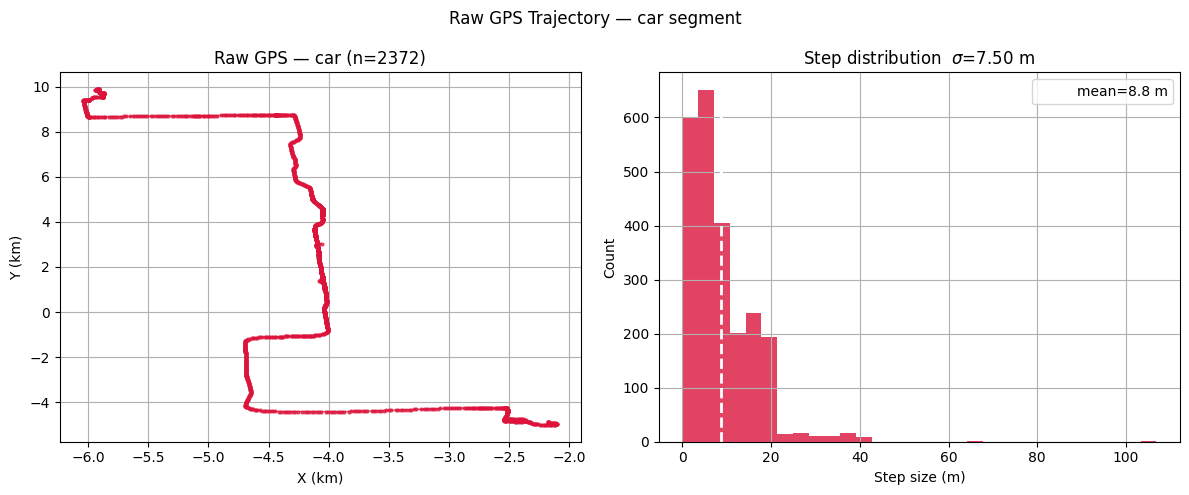

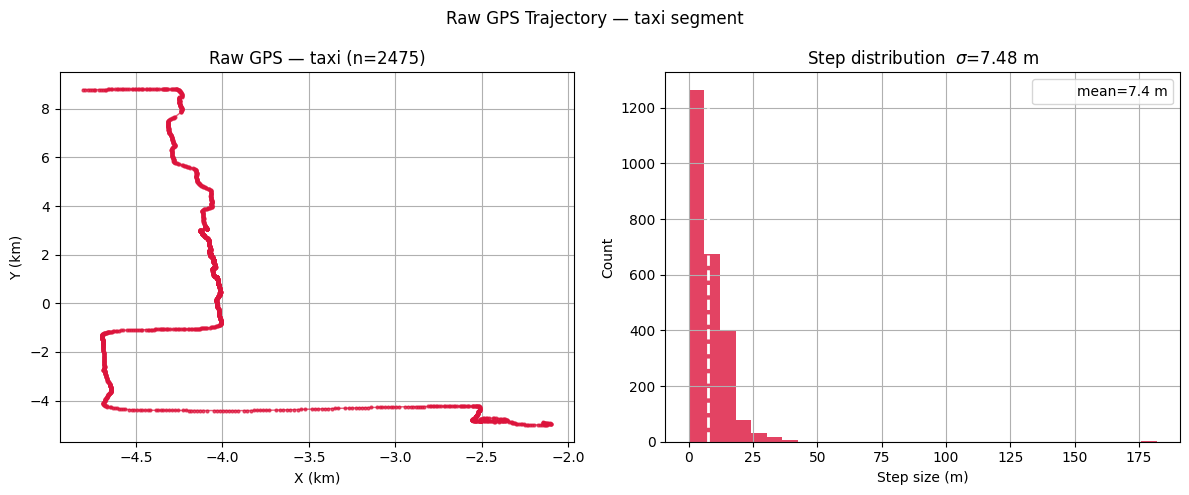

In [14]:
plot_raw_trajectory(car_seg, title='Raw GPS Trajectory — car segment')
plot_raw_trajectory(taxi_seg, title='Raw GPS Trajectory — taxi segment')

Each plot shows two panels:

- **Left** — the 2D trajectory in local Cartesian coordinates. The origin (0, 0) is the first GPS fix of the segment. Jitter on straight sections is visible as GPS noise.
- **Right** — the distribution of step sizes between consecutive fixes (1-second intervals).

The dashed white line marks the mean step size; $\sigma$ is the standard deviation — our empirical estimate of GPS positional noise.

Both car and taxi segments show a GPS positional noise of approximately **7.5 metres** (measured as the standard deviation of step sizes) — consistent with the 5–10 m accuracy range typical for consumer-grade GPS receivers in urban environments [WikipediaGPS].

The trajectory plot reveals the characteristic jitter of consumer GPS — the path appears jagged even on straight road sections. This is exactly what the Kalman filter is designed to smooth.

The step size distribution shows outliers — a few GPS jumps well beyond the typical noise level. To check how much these inflate the $\sigma_r$ estimate, `steps.std()` is compared against a robust estimator based on the Median Absolute Deviation (MAD), which is less sensitive to outlier GPS jumps.

In [15]:
for name, seg in [('car', car_seg), ('taxi', taxi_seg)]:
    _, _, steps = compute_steps(seg['df'])
    print(f"{name}: sigma={steps.std():.2f} m  max_step={steps.max():.1f} m")

car: sigma=7.50 m  max_step=106.9 m
taxi: sigma=7.48 m  max_step=181.8 m


The step size distribution shows a few large GPS jumps — outliers well beyond the typical noise. These are real GPS errors that slipped below the 500 m filter threshold. They inflate `steps.std()` slightly, but $\sigma_r = 7.5$ m is still a good fit for the bulk of the data and consistent with the 5–10 m consumer GPS accuracy range. In a real tracking scenario, $\sigma_r$ would come from the GPS receiver specification rather than the data.

## Realization 

`run_kf()` is the main filter loop — it feeds GPS fixes one at a time to class `KalmanFilter`, rebuilding $F$ and $Q$ at each step for the actual time interval $\Delta t_k$. At every update step, `KalmanFilter` logs the posterior state $s$, innovation $e$, Kalman gain $K$, measurement $z$ and covariance $P$ into class `StateLogger`.

After the filter has run, `GPSStats` reads the logged histories (`s_hist`, `e_hist`, `z_hist`) together with the raw GPS positions to compute three groups of metrics: acceleration RMS (how smooth the trajectory is), innovation norm (how well the filter tracks the measurements) and innovation statistics (whether the filter introduces any bias).

The helper functions `plot_kf_comparison()`, `plot_innovations()`, `print_acc_metrics()`, `print_innovation_metrics()` and `print_innovation_full()` visualise and print the results from `GPSStats` for each model and segment.
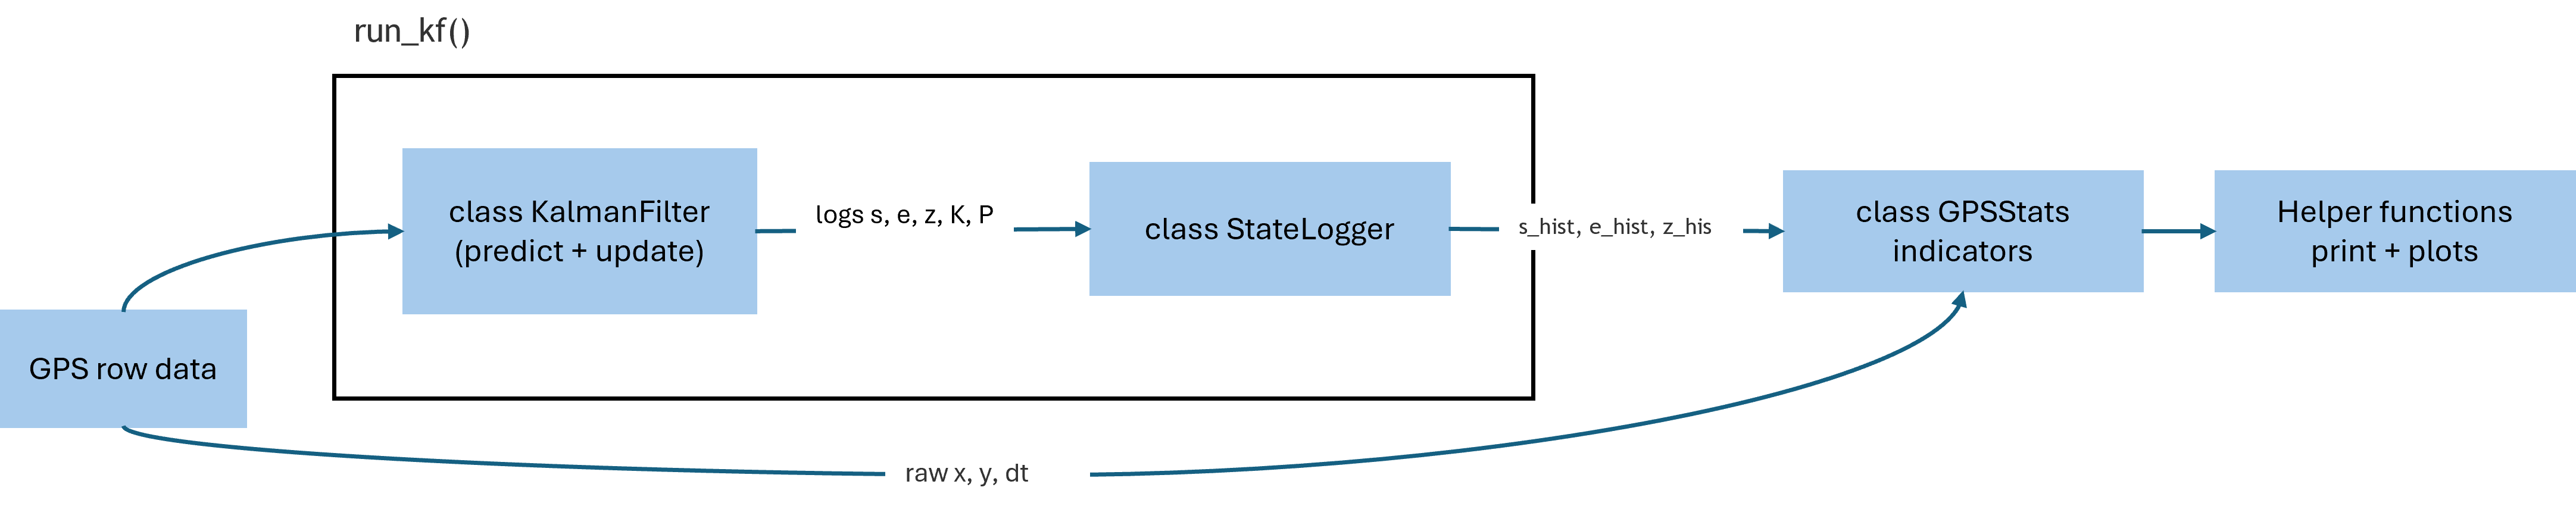
Data flow — from raw GPS through the Kalman filter to evaluation metrics.

### Descriptions of Classes and Utils

#### Class `KalmanFilter`

File `src/kalman_tracker.py` defines a generic linear Kalman filter class `KalmanFilter` for a state $s_k \in \mathbb{R}^n$ and a measurement $z_k \in \mathbb{R}^m$, with a built-in logger for all key quantities.

> [Open kalman_tracker.py](src/kalman_tracker.py)

The class accepts the standard filter matrices — $F$, $Q$, $H$, $R$ — and an optional control input matrix $B$ (default `None`, unused in our GPS application). For variable time-step applications, F_builder(dt)` and `Q_builder(dt)` can be supplied — the matrices are then rebuilt at each prediction step from the actual time interval $\Delta t_k$.

Optionally, it accepts a `StateLogger` instance which records at each step: 
states $s$, covariances $P$, Kalman gain $K$, measurements $z$, predicted measurements $\hat{z}$, and innovations $e$.

**Methods:**

**`__init__`** — stores matrices and optional logger. No logic, just configuration.  
**`predict`** — rebuilds $F$ and $Q$ for the current $\Delta t_k$ if `F_builder` is provided. Returns $(s_{k+1|k},\ P_{k+1|k})$.  
**`update`** — computes innovation, Kalman gain, corrected state and updated covariance. Logs all quantities if a logger is attached. Returns $(s_{k+1|k+1},\ P_{k+1|k+1})$.  
**`reset`** — clears the logger history. Use between segments when reusing the same instance.

#### Class `StateLogger`

`StateLogger` is a simple buffer that records the filter's internal quantities at each update step. It is initialised with a list of keys — only the quantities in that list are recorded, everything else is ignored.

> [Open state_logger.py](src/state_logger.py)

The filter records five quantities: `s` — the posterior state estimate, `z` — the raw GPS measurement, `e` — the innovation, `K` — the Kalman gain, and `P` — the covariance matrix. After the filter has run, `get_stat()` returns the full history of any requested quantity as a NumPy array, ready to be passed to `GPSStats`.

The logger is intentionally kept separate from the filter — `KalmanFilter` calls `logger.append()` at each update step, but knows nothing about what is stored or how. This makes it easy to swap loggers, add new quantities, or disable logging entirely by passing `logger=None`.

#### Class `GPSStats`

File `src/gps_stats.py` defines class `GPSStats`, which encapsulates all statistics and visualisation for a single Kalman-filtered GPS segment. It receives pre-computed buffers from the filter and raw GPS coordinates — it has no dependency on the filter itself.

> [Open gps_stats.py](src/gps_stats.py)

**Constructor parameters:**

 `s_hist` — state vector history $S \in \mathbb{R}^{N \times n}$, where $N$ is the number of steps and $n$ is the state dimension ($n=4$ for CV, $n=6$ for CA). Each row is the posterior state estimate after the update step.
 `e_hist` — innovation history $E \in \mathbb{R}^{N \times 2}$. The difference between the measurement and the predicted position at each step. For a well-tuned filter, $e_k$ should be zero-mean white noise with $\text{std}(e_k) \approx \sigma_r$.
 `z_hist` — measurement history $Z \in \mathbb{R}^{N \times 2}$. The raw GPS positions as seen by the filter.
 `x, y` — raw GPS positions in metres, $\mathbf{x}, \mathbf{y} \in \mathbb{R}^N$. Used to compute `acc_rms_raw`.
 `dt_arr` — time steps between consecutive GPS fixes in seconds, $\Delta t \in \mathbb{R}^{N-1}$. Passed to the acceleration RMS computation 
  to handle irregular sampling.
 `model` — `'cv'` or `'ca'`. Controls the guard in `acceleration_rms_state` — returns `None` for CV since the state vector has no $a_x, a_y$ components.

**Methods:**

`acc_rms_raw()` — computes the acceleration RMS of the raw GPS positions via double finite differences. Used as the baseline noise indicator before filtering.  
`acc_rms_kf_pos()` — computes the same metric on the Kalman-filtered positions extracted from `s_hist`. The reduction relative to `acc_rms_raw()` reflects how much the filter has smoothed the trajectory.  
`acceleration_rms_state()` — computes the acceleration RMS directly from the $a_x, a_y$ components of the CA state vector. Physically cleaner than `acc_rms_kf_pos()` — not amplified by numerical differentiation. Returns `None` for CV.  
`compute_metrics()` — aggregates all metrics into a single dict: `acc_raw`, `acc_kf_pos`, `acc_kf_state`, `rse_median`, `rse_p95` and the full innovation array `e`. 

#### Initial conditions

To run the Kalman filter, we must specify an initial state estimate and its error covariance:

$$
s_{0|0} \in \mathbb{R}^n, \qquad P_{0|0} \in \mathbb{R}^{n\times n},
$$

where $n = 4$ for the CV model and $n = 6$ for the CA model.

The state is initialised from the first measurement, setting unknown quantities to zero:

$$
s_{0|0} =
\begin{bmatrix}
x_0^{\text{meas}} \\ y_0^{\text{meas}} \\ 0 \\ \vdots \\ 0
\end{bmatrix} \in \mathbb{R}^n
$$

$P_{0|0}$ is initialised with position variance equal to the GPS noise ($\sigma_r^2$) and large variance for velocity and acceleration — we simply don't know them [KalmanFilterNet, Ch. 3].

##### State Transition Matrices `F_cv` and `F_ca`

Both functions build the state transition matrix $F(\Delta t)$ for a given time step $\Delta t$ directly from the kinematic equations derived in the Theory section. Both matrices are rebuilt at each prediction step because GPS sampling is irregular — $\Delta t_k$ varies between consecutive fixes.

In [16]:
def F_cv(dt):
    """
    State transition matrix for Constant Velocity model.
    State: [x, y, vx, vy]
    """
    return np.array([
        [1, 0, dt, 0 ],
        [0, 1, 0,  dt],
        [0, 0, 1,  0 ],
        [0, 0, 0,  1 ]
    ], dtype=float)

def F_ca(dt):
    """
    State transition matrix for Constant Acceleration model.
    State: [x, y, vx, vy, ax, ay]
    """
    dt2 = 0.5 * dt**2
    return np.array([
        [1, 0, dt, 0,  dt2, 0  ],
        [0, 1, 0,  dt, 0,   dt2],
        [0, 0, 1,  0,  dt,  0  ],
        [0, 0, 0,  1,  0,   dt ],
        [0, 0, 0,  0,  1,   0  ],
        [0, 0, 0,  0,  0,   1  ]
    ], dtype=float)

##### Measurement Model `H_pos` and `R_pos`

`H_pos(n)` builds the measurement matrix $H \in \mathbb{R}^{2 \times n}$ which extracts only position from the state vector — GPS receivers observe position, not velocity or acceleration. It works for both CV ($n=4$) and CA ($n=6$).

`R_pos(sigma_r)` builds the measurement noise covariance $R = \sigma_r^2 I_2$, assuming equal and independent noise in $x$ and $y$.

> **Note:** $\sigma_r \approx 7.5$ m is estimated empirically from the step size distribution of the raw trajectories — a mild data leakage.
>  In practice, this value would come from the GPS receiver specification.

In [17]:
def H_pos(n=4):
    """
    Measurement matrix — observes only position [x, y].
    Works for both CV (n=4) and CA (n=6).
    """
    H = np.zeros((2, n))
    H[0, 0] = 1
    H[1, 1] = 1
    return H

def R_pos(sigma_r=7.5):
    """
    Measurement noise covariance.
    sigma_r : float
        GPS positional noise standard deviation in metres.
        Estimated from raw data: sigma_r ≈ 7.5 m.
    """
    return sigma_r**2 * np.eye(2)


##### Process Noise `Q_cv` and `Q_ca`

Both functions build the process noise covariance $Q(\Delta t)$ using the assumption that disturbances act only on acceleration. $Q_a$ is a diagonal matrix with $\sigma_a^2$ only on the acceleration components — all other components are zero. Position and velocity inherit uncertainty from acceleration through the motion model:

$$Q = F\,Q_a\,F^\top$$

The single parameter $\sigma_a$ controls the trade-off between smoothing and model flexibility — small $\sigma_a$ trusts the model, large $\sigma_a$ follows the measurements more closely.

In [18]:
def Q_ca(dt, sigma_a=0.5):
    F = F_ca(dt)
    Qa = sigma_a**2 * np.diag([0, 0, 0, 0, 1, 1])
    return F @ Qa @ F.T

def Q_cv(dt, sigma_a=0.5):
    F = F_cv(dt)
    Qa = sigma_a**2 * np.diag([0, 0, 1, 1])
    return F @ Qa @ F.T

#### Helper functions 

`gps_sensor(seg)` is a generator that feeds one GPS fix at a time — latitude, longitude and timestamp. It simulates real-time tracking: the filter never looks ahead and processes each reading as it arrives.

`run_kf(sensor, ...)` is the main filter loop. It takes the first fix from the sensor to initialise the state, then for each subsequent fix: computes `dt`, runs `predict` and `update`, and accumulates the results. At the end, it returns the logger history together with the position arrays `xs`, `ys` and time steps `dts` for evaluation.

`plot_kf_comparison(stats_car, stats_taxi, model_name, zoom, n)` creates a side-by-side comparison of car and taxi trajectories for a given model, with a shared zoom window and a common suptitle. Uses an internal `_plot_trajectory()` helper for each panel.

`plot_innovations(stats, title)` produces a 2×2 diagnostic figure — innovation time series for $e_x$ and $e_y$ (top) and their distributions (bottom). Prints a summary table with mean, std, min and max for each axis. Uses internal `_plot_innovation_series()` and `_plot_innovation_hist()` helpers.

`shared_zoom(xs1, ys1, xs2, ys2)` computes a bounding box that covers the last `n` points of both segments, with a small `margin` on each side. 
Used to set a consistent zoom window across the car and taxi trajectory plots. `_last_km(xs, ys, n)` converts the last `n` positions from metres to kilometres — a small utility used to prepare coordinates for zoom computation.

`print_acc_metrics(title, results)` prints the acceleration RMS table. Automatically adds the `acc_kf_state` column when the results contain CA model data — CV rows show `—` in that column.

`print_innovation_metrics(title, results)` prints a compact table with `rse_median` and `rse_p95` — the median and 95th percentile of the innovation norm $\|e_k\|$ for each segment.

`print_innovation_full(title, results)` prints the full innovation statistics table — mean, std and max of $e_x$ and $e_y$ for each segment.


In [19]:
def gps_sensor(seg):
    """Yield one GPS fix at a time — simulates real-time sensor stream."""
    for _, row in seg['df'].iterrows():
        yield row['lat'], row['lon'], row['ts']

def run_kf(sensor, F0, Q0, H, R, F_builder, Q_builder, n, sigma_r=7.5):
    """
    Run the Kalman filter over a GPS segment.
    Returns logger, xs, ys, dts.
    """
    # First fix — initialise state and covariance
    lat0, lon0, ts0 = next(sensor)
    x0, y0 = to_xy(lat0, lon0)
    s = np.zeros((n, 1))
    s[0, 0] = x0
    s[1, 0] = y0
    P = np.diag([sigma_r**2, sigma_r**2] + [1000.] * (n - 2))

    # Kalman filter — F and Q are rebuilt at each step for irregular dt
    logger  = StateLogger(["s", "z", "e", "K", "P"])
    kf      = KalmanFilter(F0, Q0, H, R, logger,
                           F_builder=F_builder,
                           Q_builder=Q_builder)
    ts_prev = ts0
    xs, ys, dts = [x0], [y0], []

    # Predict-update cycle
    for lat, lon, ts in sensor:
        x, y = to_xy(lat, lon)
        dt_k = (ts - ts_prev).total_seconds()
        dt_k = np.clip(dt_k, 0.1, 30.0)  # guard: avoid zero dt and GPS dropouts
        z    = np.array([[x], [y]])
        s, P = kf.predict(s, P, dt=dt_k)
        s, P = kf.update(s, P, z)
        ts_prev = ts
        xs.append(x)
        ys.append(y)
        dts.append(dt_k)

    return logger, np.array(xs), np.array(ys), np.array(dts)

def plot_kf_comparison(stats_car, stats_taxi, model_name, zoom, n):
    """Side-by-side trajectory comparison for car and taxi segments."""
    def _plot_trajectory(stats, ax, title='', zoom=None):
        """Plot raw GPS vs KF estimate on a single axis."""
        kx, ky = stats.s_hist[:, 0], stats.s_hist[:, 1]
        mx, my = stats.z_hist[:, 0], stats.z_hist[:, 1]
        ax.plot(mx/1000, my/1000, 'o-', color='crimson',
                ms=2, lw=1, alpha=0.7, label='raw GPS')
        ax.plot(kx/1000, ky/1000, 'b-', lw=1.5, label='KF estimate')
        ax.set_xlabel('X (km)'); ax.set_ylabel('Y (km)')
        ax.grid(True); ax.legend()
        ax.set_title(title or f"{stats.model.upper()} (n={len(kx)})")
        if zoom:
            ax.set_xlim(zoom[0], zoom[1])
            ax.set_ylim(zoom[2], zoom[3])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    _plot_trajectory(stats_car,  axes[0], title=f"{model_name} — car",  zoom=zoom)
    _plot_trajectory(stats_taxi, axes[1], title=f"{model_name} — taxi", zoom=zoom)
    plt.suptitle(f"{model_name} — σ_r=7.5m, σ_a=0.5m/s², last N={n} points")
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_innovations(stats, title=''):
    """
    2x2 diagnostic figure — innovation time series (top) and 
    distributions (bottom). Prints summary statistics.
    """
    def _plot_innovation_series(ax, data, label):
        """Time series of innovation with zero-mean reference line."""
        ax.plot(data, 'b-', lw=0.8, label=f'innovation ${label}$')
        ax.axhline(0, color='r', ls='--', label='zero mean')
        ax.set_title(f'Innovation ${label}$')
        ax.legend(); ax.grid(True)

    def _plot_innovation_hist(ax, data, label):
        """Histogram of innovation with mean marker."""
        ax.hist(data, bins=30, color='steelblue', alpha=0.8)
        ax.axvline(data.mean(), color='r', ls='--', label=f'mean={data.mean():.2f}')
        ax.set_title(f'${label}$ distribution  $\\sigma$={data.std():.2f} m')
        ax.legend(); ax.grid(True)

    ex, ey = stats.e_hist[:, 0], stats.e_hist[:, 1]
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    _plot_innovation_series(axes[0, 0], ex, 'e_x')
    _plot_innovation_series(axes[0, 1], ey, 'e_y')
    _plot_innovation_hist(axes[1, 0], ex, 'e_x')
    _plot_innovation_hist(axes[1, 1], ey, 'e_y')
    plt.suptitle(title or f'Innovation analysis — {stats.model.upper()}')
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"{'':>6} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
    print(f"{'':>6} {'(m)':>10} {'(m)':>10} {'(m)':>10} {'(m)':>10}")
    print("-" * 46)
    print(f"{'ex':>6} {ex.mean():10.3f} {ex.std():10.3f} {ex.min():10.3f} {ex.max():10.3f}")
    print(f"{'ey':>6} {ey.mean():10.3f} {ey.std():10.3f} {ey.min():10.3f} {ey.max():10.3f}")


def shared_zoom(xs1, ys1, xs2, ys2, n=200, margin=0.2):
    def _last_km(xs, ys, n=200):
        return np.array(xs[-n:]) / 1000, np.array(ys[-n:]) / 1000
        
    x1, y1 = _last_km(xs1, ys1, n)
    x2, y2 = _last_km(xs2, ys2, n)
    x = np.concatenate([x1, x2])
    y = np.concatenate([y1, y2])
    return (x.min() - margin, x.max() + margin,
            y.min() - margin, y.max() + margin)

def print_acc_metrics(title, results):
    has_state = any(m['acc_kf_state'] is not None for _, m in results)
    print(f"\n{title}")
    print(f"{'':>6} {'acc_raw':>10} {'acc_kf_pos':>12}" + f" {'acc_kf_state':>14}" * has_state + f" {'imp%':>8}")
    print("-" * (40 + 14 * has_state))
    for name, m in results:
        imp   = (1 - m['acc_kf_pos'] / m['acc_raw']) * 100
        state = f"{m['acc_kf_state']:14.3f}" if m['acc_kf_state'] is not None else f"{'—':>14}"
        print(f"{name:>6} {m['acc_raw']:10.3f} {m['acc_kf_pos']:12.3f}" + f" {state}" * has_state + f" {imp:8.1f}%")

def print_innovation_metrics(title, results):
    print(f"\n{title}")
    print(f"{'':>6} {'rse_median':>12} {'rse_p95':>10}")
    print(f"{'':>6} {'(m)':>12} {'(m)':>10}")
    print("-" * 32)
    for name, m in results:
        print(f"{name:>6} {m['rse_median']:12.3f} {m['rse_p95']:10.3f}")

def print_innovation_full(title, results):
    print(f"\n{title}")
    print(f"| {'':7} | {'ex_mean (m)':>12} | {'ex_std (m)':>12} | {'ex_max (m)':>12} | {'ey_mean (m)':>12} | {'ey_std (m)':>12} | {'ey_max (m)':>12} |")
    print(f"|{'-'*9}|{'-'*14}|{'-'*14}|{'-'*14}|{'-'*14}|{'-'*14}|{'-'*14}|")
    for name, m in results:
        e = m['e']
        print(f"| {name:7} | {e[:,0].mean():12.2f} | {e[:,0].std():12.2f} | {e[:,0].max():12.2f} | {e[:,1].mean():12.2f} | {e[:,1].std():12.2f} | {e[:,1].max():12.2f} |")

### GPS Kalman Filter in Action

The filter is applied to two motion models — CV and CA — on the same two GPS segments (car and taxi). For each model, the following analysis is performed according to the Statistics section:

* acceleration RMS — measures how much the filter reduced trajectory jitter. Reports `acc_raw`, `acc_kf_pos` and `imp%` for both segments. For CA, `acc_kf_state` is also reported — acceleration taken directly from the state vector.
* innovation norm — measures how well the filter predicts each GPS fix. Reports `rse_median` and `rse_p95` for both segments.
* innovation statistics — checks whether the filter introduces any systematic bias. Reports mean, std and max of $e_x$ and $e_y$ for both segments.

At the end, CV and CA are compared side by side — acceleration RMS and innovation statistics for all four combinations (car CV, car CA, taxi CV, taxi CA).

The section closes with **Covariance Matrix Convergence** (CA model, car segment) and **Parameter tuning** — the CA filter re-run with varying $\sigma_a$ to show the smoothing trade-off.

#### CV model (4D)

The Constant Velocity filter is applied to both segments with the following parameters:

- $\sigma_r = 7.5$ m — estimated from the raw GPS step distribution
- $\sigma_a = 0.5$ m/s² — process noise for the CV model

`run_kf_cv` wraps `run_kf` with the 4D matrices — `F_cv`, `Q_cv`, `H_pos(4)` and `R_pos` — and returns the logger history together with the raw position arrays `xs`, `ys` and time steps `dts`.

The logger buffers `s`, `e`, `z` are passed to `GPSStats`, which computes the metrics. `m_car_cv` and `m_taxi_cv` are dicts containing `acc_raw`, `acc_kf_pos`, `rse_median`, `rse_p95` and the full innovation array `e`.

`run_kf_cv` is a thin wrapper around `run_kf` that fixes the CV-specific matrices — `F_cv`, `Q_cv`, `H_pos(4)` and `R_pos` — exposing only `sigma_r` and `sigma_a` as tunable parameters.

In [20]:
def run_kf_cv(sensor, sigma_r=7.5, sigma_a=0.5):
    return run_kf(sensor,
                  F0       = F_cv(1.0),
                  Q0       = Q_cv(1.0, sigma_a),
                  H        = H_pos(n=4),
                  R        = R_pos(sigma_r),
                  F_builder= F_cv,
                  Q_builder= lambda dt: Q_cv(dt, sigma_a),
                  n        = 4,
                  sigma_r  = sigma_r)

The filter is run on both segments. The logger buffers `s`, `e`, `z` are extracted and passed to `GPSStats`. Metrics are computed with `compute_metrics()` and stored in `m_car_cv` and `m_taxi_cv`.



In [21]:
car_logger, car_xs, car_ys, car_dts = run_kf_cv(gps_sensor(car_seg))
s, e, z = car_logger.get_stat(["s", "e", "z"])
car_cv  = GPSStats(s, e, z, car_xs, car_ys, car_dts, model='cv')

taxi_logger, taxi_xs, taxi_ys, taxi_dts = run_kf_cv(gps_sensor(taxi_seg))
s, e, z = taxi_logger.get_stat(["s", "e", "z"])
taxi_cv = GPSStats(s, e, z, taxi_xs, taxi_ys, taxi_dts, model='cv')

m_car_cv  = car_cv.compute_metrics()
m_taxi_cv = taxi_cv.compute_metrics()

* **Acceleration RMS**

The trajectory plot uses a `zoom` tuple to focus on a representative section of the path — making the smoothing effect visible at street level.

The metrics table reports `acc_raw`, `acc_kf_pos`, `imp%`, `rse_median` and `rse_p95` for both segments.

In [22]:
n = 200
margin = 0.2
zoom = shared_zoom(car_xs, car_ys, taxi_xs, taxi_ys, n=n, margin = margin)
print(f"last points: {n}, margin:{margin}, zoom:  {zoom}")

last points: 200, margin:0.2, zoom:  (np.float64(-2.7563382819420985), np.float64(-1.899148652605984), np.float64(-5.203882893931697), np.float64(-4.0550962579070635))


The plot below shows the raw GPS path (red) against the CV filter estimate (blue) for both segments. The table below reports how much the filter reduced the acceleration noise — `acc_kf_pos` vs `acc_raw`, and the relative improvement `imp%`. CV smooths aggressively because it has no acceleration state — any sudden manoeuvre shows up as a large correction.

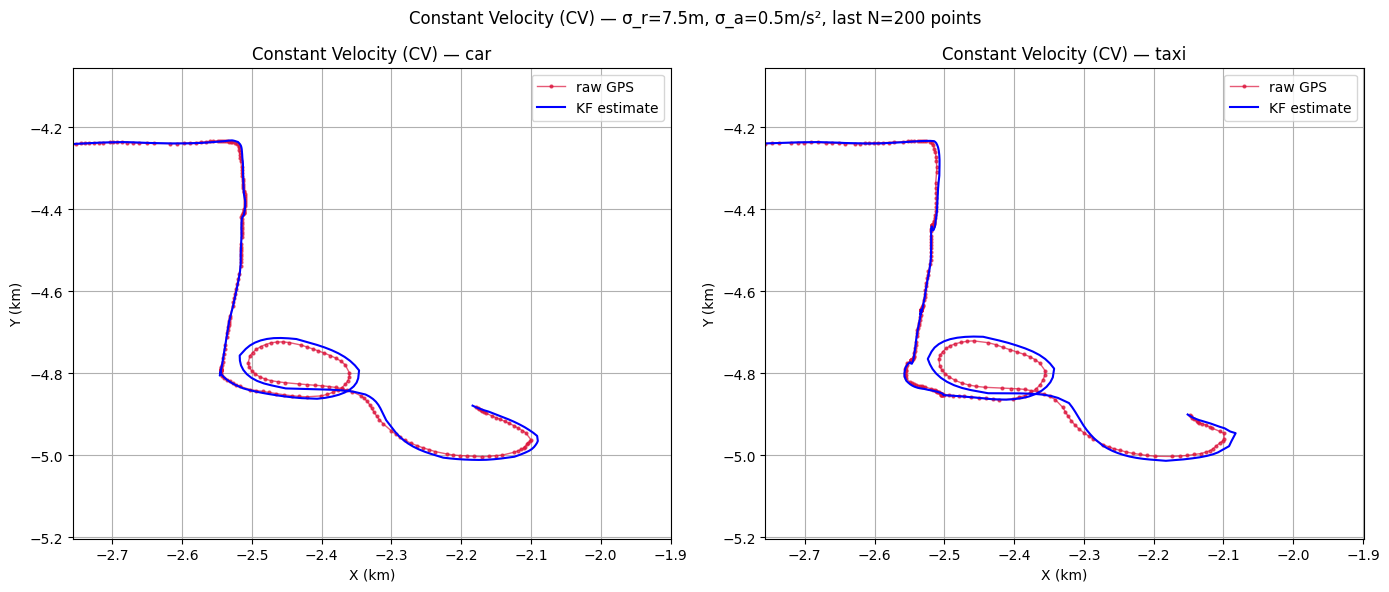


CV Kalman Filter — sigma_r=7.5m, sigma_a=0.5m/s^2
          acc_raw   acc_kf_pos     imp%
----------------------------------------
   car      2.085        0.968     53.6%
  taxi      1.628        0.953     41.4%


In [23]:
plot_kf_comparison(car_cv, taxi_cv, "Constant Velocity (CV)", zoom, n)

print_acc_metrics(f"CV Kalman Filter — sigma_r=7.5m, sigma_a=0.5m/s^2", [('car', m_car_cv), ('taxi', m_taxi_cv)])

Both segments show a reduction in acceleration RMS after filtering.

* **Innovation norm — CV model**

The innovation $e_k = z_k - H s_{k|k-1}$ is plotted for each axis. For a well-tuned filter the time series should be zero-mean and the distribution approximately Gaussian with $\text{std} \approx \sigma_r$.

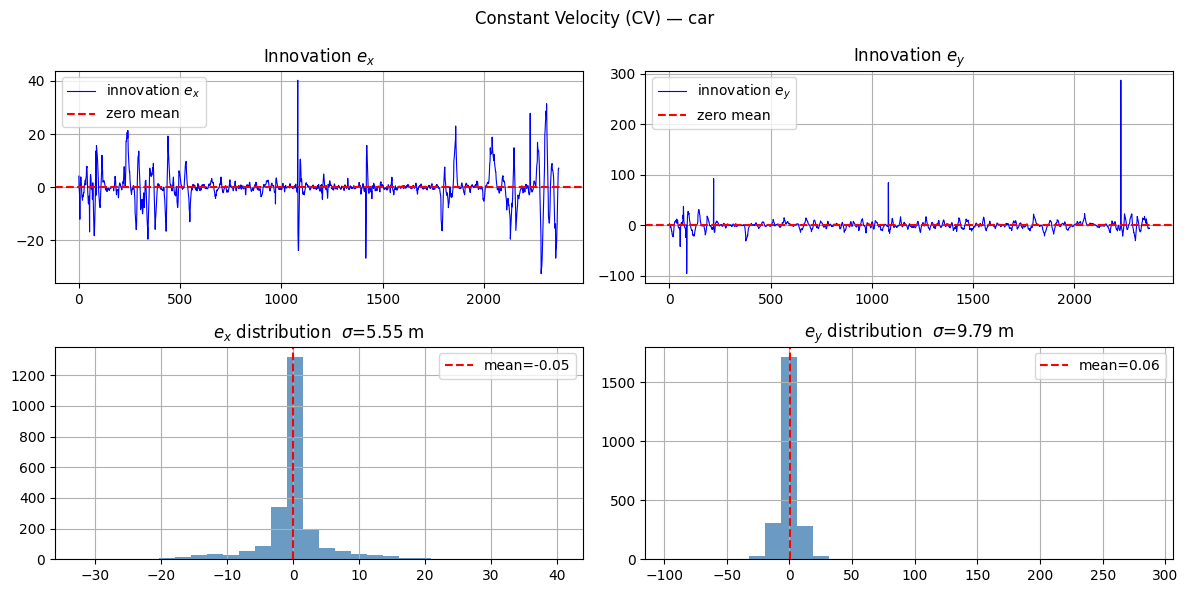

             mean        std        min        max
              (m)        (m)        (m)        (m)
----------------------------------------------
    ex     -0.051      5.551    -32.499     40.281
    ey      0.063      9.792    -95.814    287.330


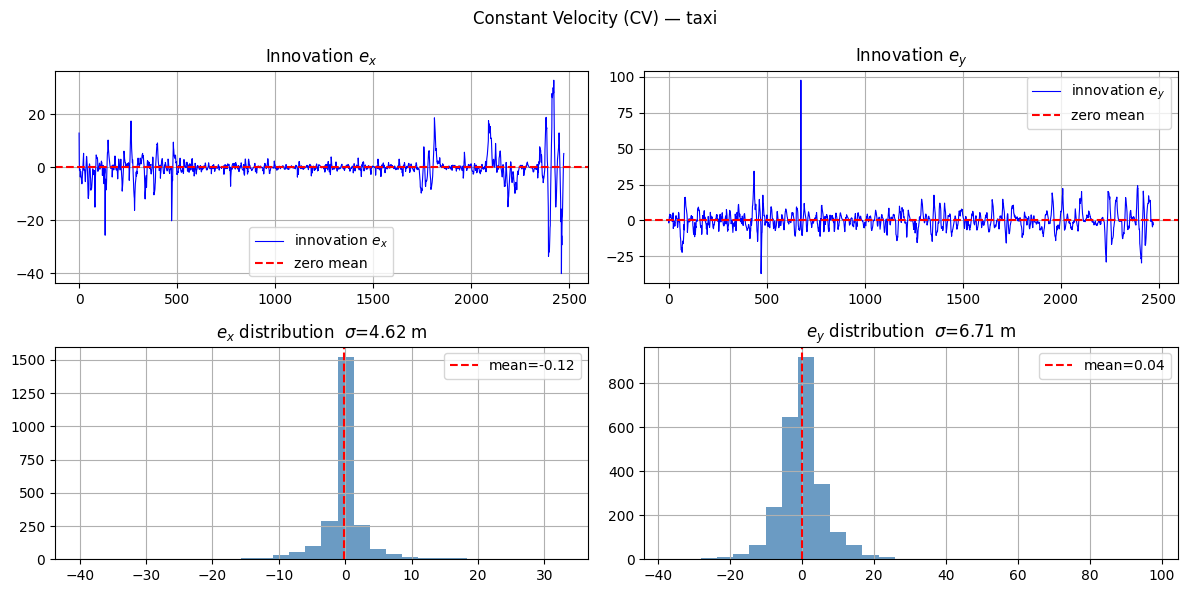

             mean        std        min        max
              (m)        (m)        (m)        (m)
----------------------------------------------
    ex     -0.117      4.623    -40.093     32.925
    ey      0.038      6.706    -37.078     97.687

CV Kalman Filter — sigma_r=7.5 m, sigma_a=0.5 m/s²
         rse_median    rse_p95
                (m)        (m)
--------------------------------
   car        4.766     19.399
  taxi        4.107     16.328


In [24]:
plot_innovations(car_cv,  title="Constant Velocity (CV) — car")
plot_innovations(taxi_cv, title="Constant Velocity (CV) — taxi")

print_innovation_metrics(
    "CV Kalman Filter — sigma_r=7.5 m, sigma_a=0.5 m/s²",
    [('car', m_car_cv), ('taxi', m_taxi_cv)]
)

Median RSE of **4.1–4.8 m** for both segments — well within the GPS noise level of $\sigma_r = 7.5 m$. rse_p95 of **16–19 m**.

* **Innovation statistics**

Both segments show mean ≈ 0 — no systematic bias.

In [25]:
print_innovation_full("CV model — innovation statistics (ex, ey) per segment",
                      [('car', m_car_cv), ('taxi', m_taxi_cv)])


CV model — innovation statistics (ex, ey) per segment
|         |  ex_mean (m) |   ex_std (m) |   ex_max (m) |  ey_mean (m) |   ey_std (m) |   ey_max (m) |
|---------|--------------|--------------|--------------|--------------|--------------|--------------|
| car     |        -0.05 |         5.55 |        40.28 |         0.06 |         9.79 |       287.33 |
| taxi    |        -0.12 |         4.62 |        32.93 |         0.04 |         6.71 |        97.69 |


Both segments show $e_y > e_x$.

#### CA model (6D)

The Constant Acceleration filter is applied to the same segments with the same parameters — $\sigma_r = 7.5$ m, $\sigma_a = 0.5 m/s^2$.

`run_kf_ca` wraps `run_kf` with the 6D matrices — `F_ca`, `Q_ca`, `H_pos(6)` and `R_pos`. The state now includes $a_x, a_y$ explicitly.

The raw position arrays `car_xs`, `car_ys`, `car_dts` are reused from the CV run — they come from the raw GPS signal, independent of the motion model.

`m_car_ca` and `m_taxi_ca` include an additional metric — `acc_kf_state`, available only for CA.

In [26]:
def run_kf_ca(sensor, sigma_r=7.5, sigma_a=0.5):
    return run_kf(sensor,
                  F0       = F_ca(1.0),
                  Q0       = Q_ca(1.0, sigma_a),
                  H        = H_pos(n=6),
                  R        = R_pos(sigma_r),
                  F_builder= F_ca,
                  Q_builder= lambda dt: Q_ca(dt, sigma_a),
                  n        = 6,
                  sigma_r  = sigma_r)

In [27]:
car_logger_ca,  car_xs_ca,  car_ys_ca,  car_dts_ca  = run_kf_ca(gps_sensor(car_seg))
taxi_logger_ca, taxi_xs_ca, taxi_ys_ca, taxi_dts_ca = run_kf_ca(gps_sensor(taxi_seg))

s, e, z = car_logger_ca.get_stat(["s", "e", "z"])
car_ca  = GPSStats(s, e, z, car_xs_ca, car_ys_ca, car_dts_ca, model='ca')

s, e, z = taxi_logger_ca.get_stat(["s", "e", "z"])
taxi_ca = GPSStats(s, e, z, taxi_xs_ca, taxi_ys_ca, taxi_dts_ca, model='ca')

m_car_ca  = car_ca.compute_metrics()
m_taxi_ca = taxi_ca.compute_metrics()

* **Acceleration RMS**

Zoom window for the CA trajectory plots — same approach as CV, recomputed using the CA filtered positions `car_xs_ca`, `car_ys_ca`.

In [28]:
n = 200
margin = 0.2
zoom = shared_zoom(car_xs_ca, car_ys_ca, taxi_xs_ca, taxi_ys_ca, n=n, margin=margin)
print(f"last points: {n}, margin:{margin}, zoom:  {zoom}")

last points: 200, margin:0.2, zoom:  (np.float64(-2.7563382819420985), np.float64(-1.899148652605984), np.float64(-5.203882893931697), np.float64(-4.0550962579070635))


CA filter results — trajectory comparison and acceleration RMS metrics for car and taxi segments.

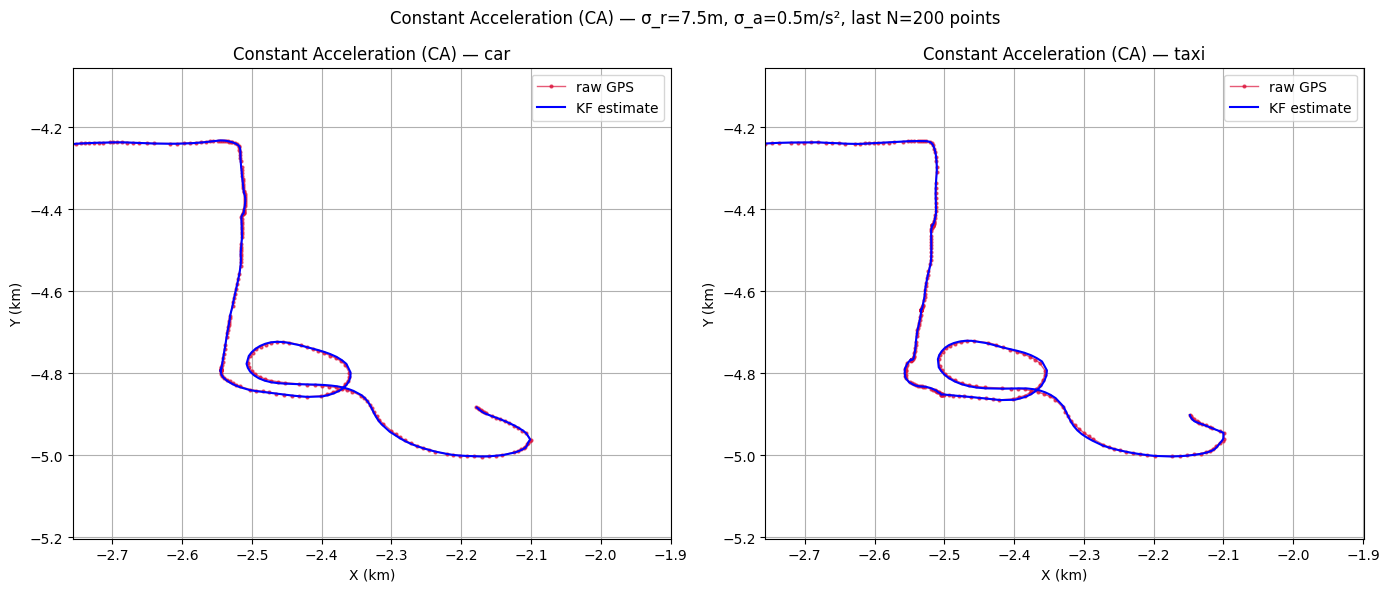


CA Kalman Filter — sigma_r=7.5m, sigma_a=0.5m/s^2
          acc_raw   acc_kf_pos   acc_kf_state     imp%
------------------------------------------------------
   car      2.085        1.172          0.550     43.8%
  taxi      1.628        0.978          0.487     39.9%


In [29]:
plot_kf_comparison(car_ca, taxi_ca, "Constant Acceleration (CA)", zoom, n)

print_acc_metrics(
    "CA Kalman Filter — sigma_r=7.5m, sigma_a=0.5m/s^2",
    [('car', m_car_ca), ('taxi', m_taxi_ca)]
)

CV shows a larger reduction in `acc_kf_pos` than CA for both segments. `acc_kf_state` (CA only) is consistently lower than `acc_kf_pos` — the state vector acceleration is smoother than the finite-difference estimate.


In [30]:
print_acc_metrics("Acceleration RMS — CV vs CA",
                  [('car CV', m_car_cv), ('car CA', m_car_ca),
                   ('taxi CV', m_taxi_cv), ('taxi CA', m_taxi_ca)])


Acceleration RMS — CV vs CA
          acc_raw   acc_kf_pos   acc_kf_state     imp%
------------------------------------------------------
car CV      2.085        0.968              —     53.6%
car CA      2.085        1.172          0.550     43.8%
taxi CV      1.628        0.953              —     41.4%
taxi CA      1.628        0.978          0.487     39.9%


The table above summarises the innovation statistics for the CV model — mean, standard deviation and maximum of $e_x$ and $e_y$ across all steps. Mean $\approx$ 0 for both segments confirms no systematic bias. std reflects typical prediction error per axis; max captures residual GPS jumps not removed 
by outlier filtering.

#### Innovation — CV vs CA

Innovation diagnostics for the CA model — time series and distributions of $e_x$ and $e_y$ for each segment, followed by median and 95th percentile of the innovation norm.

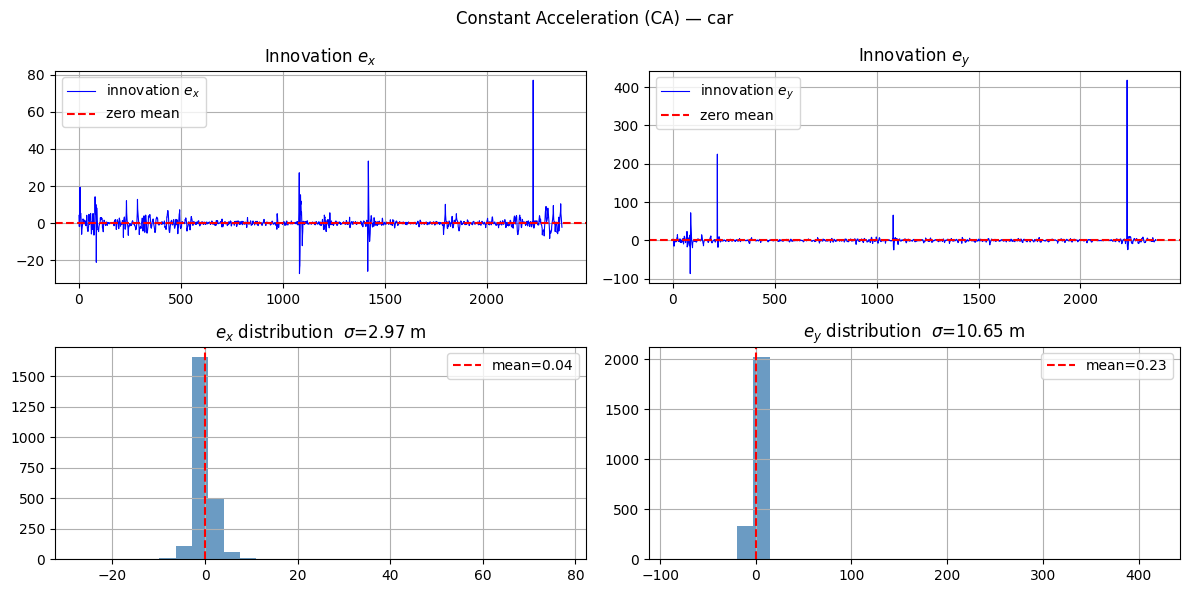

             mean        std        min        max
              (m)        (m)        (m)        (m)
----------------------------------------------
    ex      0.037      2.969    -27.228     77.082
    ey      0.232     10.654    -86.525    418.054


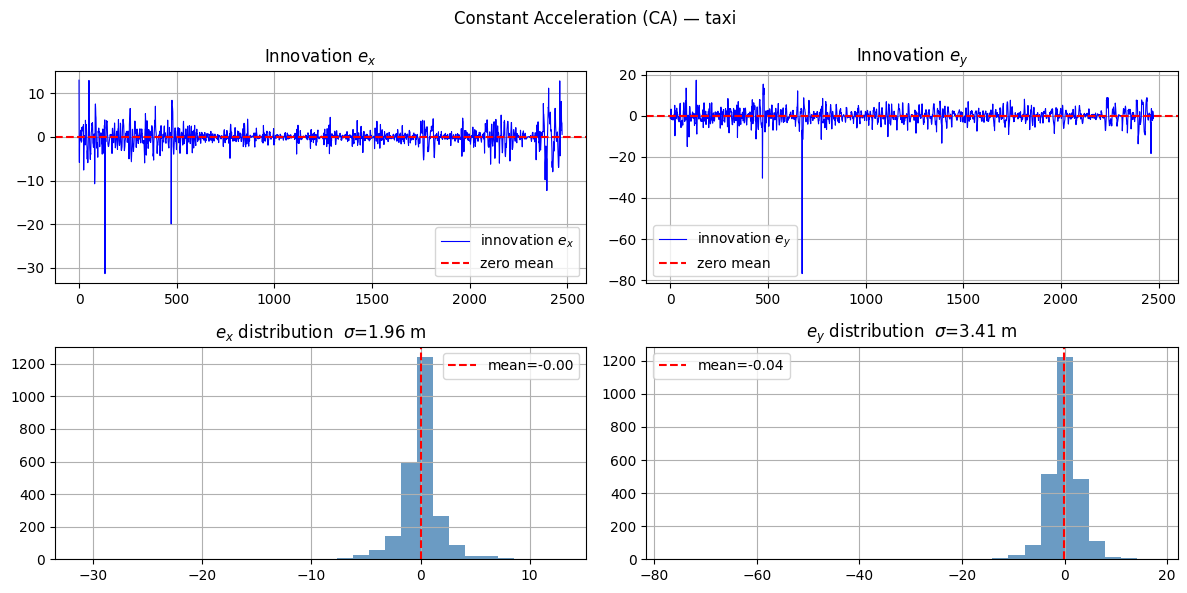

             mean        std        min        max
              (m)        (m)        (m)        (m)
----------------------------------------------
    ex     -0.001      1.956    -31.299     12.965
    ey     -0.039      3.406    -76.841     17.311


CA Kalman Filter — sigma_r=7.5 m, sigma_a=0.5 m/s²
         rse_median    rse_p95
                (m)        (m)
--------------------------------
   car        1.930      7.706
  taxi        2.113      6.864


In [31]:
plot_innovations(car_ca,  title="Constant Acceleration (CA) — car")
plot_innovations(taxi_ca, title="Constant Acceleration (CA) — taxi")
print()
print_innovation_metrics(
    "CA Kalman Filter — sigma_r=7.5 m, sigma_a=0.5 m/s²",
    [('car', m_car_ca), ('taxi', m_taxi_ca)]
)


CA reduces rse_median sharply compared to CV (car: 4.77 to 1.93 m, taxi: 4.11 to 2.11 m). 
rse_p95 also drops (car: 19.4 to 7.7 m, taxi: 16.3 to 6.9 m).

In [32]:
print_innovation_full("Innovation statistics — CV vs CA", 
                      [('car CV', m_car_cv), ('car CA', m_car_ca),
                       ('taxi CV', m_taxi_cv), ('taxi CA', m_taxi_ca)])


Innovation statistics — CV vs CA
|         |  ex_mean (m) |   ex_std (m) |   ex_max (m) |  ey_mean (m) |   ey_std (m) |   ey_max (m) |
|---------|--------------|--------------|--------------|--------------|--------------|--------------|
| car CV  |        -0.05 |         5.55 |        40.28 |         0.06 |         9.79 |       287.33 |
| car CA  |         0.04 |         2.97 |        77.08 |         0.23 |        10.65 |       418.05 |
| taxi CV |        -0.12 |         4.62 |        32.93 |         0.04 |         6.71 |        97.69 |
| taxi CA |        -0.00 |         1.96 |        12.97 |        -0.04 |         3.41 |        17.31 |


Both segments show mean $\approx$ 0 — no systematic bias in either model.

CA reduces $e_x$ std for both segments (car: 5.55 to 2.97 m, taxi: 4.62 to 1.96 m) and $e_x$ max stays small.

For taxi, $e_y$ also improves across all metrics (std: 6.71 to 3.41 m, max: 97 to 17 m).
For car, $e_y$ std slightly worsens (9.79 to 10.65 m) and max grows (287 to 418 m).

#### Covariance Matrix Convergence

> Visualization approach inspired by [balzer82/Kalman].

The initial $P_{0|0}$ is constructed inside `run_kf` from the filter parameters. The final $P_{N|N}$ is retrieved from the logger after the filter has run. Both are visualised as heatmaps and printed for inspection.

`print_matrix(M, name, labels)` prints a labelled matrix in tabular format — used to inspect $P_{0|0}$ and $P_{N|N}$ side by side.

`plot_covariance(ax, M, title, labels)` renders a covariance matrix as a heatmap — darker cells indicate larger values. Used to visualise how uncertainty is distributed across state variables.

In [33]:
def print_matrix(M, name, labels):
    """Print a labelled matrix in tabular format."""
    n = len(labels)
    w = max(len(l) for l in labels) + 1
    header = f"{'':{w}} " + "  ".join(f"{l:>10}" for l in labels)
    print(f"{name}")
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    for i, row in enumerate(M):
        vals = "  ".join(f"{v:10.2f}" for v in row)
        print(f"{labels[i]:{w}} {vals}")
    print()

def plot_covariance(ax, M, title, labels):
    """Plot a covariance matrix as a heatmap with colorbar."""
    im = ax.imshow(M, interpolation="none", cmap=plt.get_cmap('binary'))
    ax.set_title(title)
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels, fontsize=12)
    ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, fontsize=12)
    # Attach colorbar to the right of the axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", "5%", pad="3%")
    plt.colorbar(im, cax=cax)

How confident is the filter — before and after? `P` tracks the filter's uncertainty about each state variable. 

* large values mean high uncertainty; 
* small values mean the filter is confident.

The two heatmaps show how `P` changes from the initial guess to the final estimate after processing all GPS points.

P_0|0
---------------------------------------------------------------------------
              x           y         v_x         v_y         a_x         a_y
---------------------------------------------------------------------------
x         56.25        0.00        0.00        0.00        0.00        0.00
y          0.00       56.25        0.00        0.00        0.00        0.00
v_x        0.00        0.00     1000.00        0.00        0.00        0.00
v_y        0.00        0.00        0.00     1000.00        0.00        0.00
a_x        0.00        0.00        0.00        0.00     1000.00        0.00
a_y        0.00        0.00        0.00        0.00        0.00     1000.00

P_N|N
---------------------------------------------------------------------------
              x           y         v_x         v_y         a_x         a_y
---------------------------------------------------------------------------
x         30.94        0.00       12.31        0.00        2.45        0.00

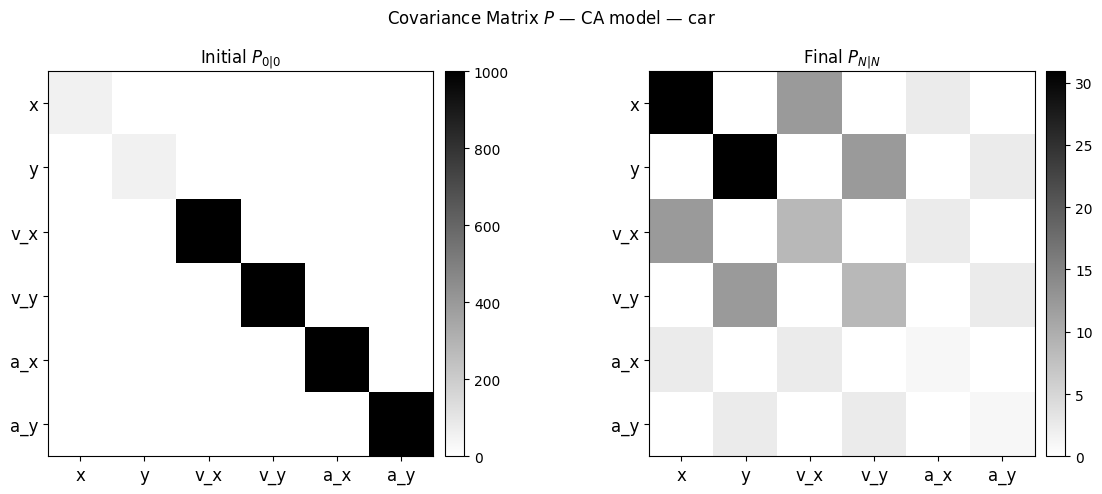

In [34]:
labels_ca = ['x', 'y', 'v_x', 'v_y', 'a_x', 'a_y']

P0 = np.diag([7.5**2, 7.5**2] + [1000.] * 4)
P_hist  = car_logger_ca.get_stat("P")
P_final = P_hist[-1]

print_matrix(P0,      "P_0|0", labels_ca)
print_matrix(P_final, "P_N|N", labels_ca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_covariance(axes[0], P0,      'Initial $P_{0|0}$', labels_ca)
plot_covariance(axes[1], P_final, 'Final $P_{N|N}$',   labels_ca)
plt.suptitle('Covariance Matrix $P$ — CA model — car')
plt.tight_layout()
plt.show()

After running the CA filter over all $N$ steps, the covariance matrix converges from the initial uncertainty to a much tighter estimate.

**Position** uncertainty drops from $56.25\ \text{m}^2$ to $30.94\ \text{m}^2$ — a modest reduction, reflecting that GPS noise is the dominant factor and cannot be eliminated by the filter.

**Velocity** uncertainty drops from $1000\ \text{m}^2/\text{s}^2$ to $8.65\ \text{m}^2/\text{s}^2$ — the filter has learned the velocity reliably from the sequence of position measurements.

**Acceleration** uncertainty drops from $1000\ \text{m}^2/\text{s}^4$ to $0.99\ \text{m}^2/\text{s}^4$ — consistent with $\sigma_a = 0.5\ \text{m/s}^2$ set at initialisation.

The x/y cross-correlations are zero throughout — the two axes are independent, as expected for a filter with no coupling between $x$ and $y$ in $F$ or $Q$.

The convergence confirms that the filter is actively smoothing — not just passing raw GPS data through.

#### Parameter tuning — $\sigma_a$

The CA filter is re-run on each segment with increasing values of $\sigma_a \in \{0.1, 0.5, 1.0, 2.0, 5.0\} \text{m/s}^2$. At each iteration, a fresh `GPSStats` instance is created from the logger buffers and `compute_metrics()` is called. This gives a direct view of how $\sigma_a$  affects the trade-off between smoothing (`acc_kf_pos`, `imp%`) and prediction accuracy (`rse_median`, `rse_p95`).

In [35]:
for sigma_a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    logger, xs, ys, dts = run_kf_ca(gps_sensor(car_seg), sigma_a=sigma_a)
    s, e, z = logger.get_stat(["s", "e", "z"])
    stats   = GPSStats(s, e, z, xs, ys, dts, model='ca')
    m       = stats.compute_metrics()
    imp     = (1 - m['acc_kf_pos'] / m['acc_raw']) * 100
    print(f"sigma_a={sigma_a:.1f}  acc_imp={imp:.1f}%  acc_kf_state={m['acc_kf_state']:.3f}  rse_med={m['rse_median']:.2f}  rse_p95={m['rse_p95']:.2f}")

sigma_a=0.1  acc_imp=48.4%  acc_kf_state=0.430  rse_med=4.26  rse_p95=17.01
sigma_a=0.5  acc_imp=43.8%  acc_kf_state=0.550  rse_med=1.93  rse_p95=7.71
sigma_a=1.0  acc_imp=38.1%  acc_kf_state=0.628  rse_med=1.41  rse_p95=5.50
sigma_a=2.0  acc_imp=31.6%  acc_kf_state=0.742  rse_med=1.06  rse_p95=4.31
sigma_a=5.0  acc_imp=22.8%  acc_kf_state=0.965  rse_med=0.83  rse_p95=3.26


In [36]:
for sigma_a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    logger, xs, ys, dts = run_kf_ca(gps_sensor(taxi_seg), sigma_a=sigma_a)
    s, e, z = logger.get_stat(["s", "e", "z"])
    stats   = GPSStats(s, e, z, xs, ys, dts, model='ca')
    m       = stats.compute_metrics()
    imp     = (1 - m['acc_kf_pos'] / m['acc_raw']) * 100
    print(f"sigma_a={sigma_a:.1f}  acc_imp={imp:.1f}%  acc_kf_state={m['acc_kf_state']:.3f}  rse_med={m['rse_median']:.2f}  rse_p95={m['rse_p95']:.2f}")

sigma_a=0.1  acc_imp=-1.4%  acc_kf_state=0.385  rse_med=3.98  rse_p95=14.18
sigma_a=0.5  acc_imp=39.9%  acc_kf_state=0.487  rse_med=2.11  rse_p95=6.86
sigma_a=1.0  acc_imp=34.3%  acc_kf_state=0.538  rse_med=1.67  rse_p95=5.48
sigma_a=2.0  acc_imp=29.1%  acc_kf_state=0.605  rse_med=1.32  rse_p95=4.87
sigma_a=5.0  acc_imp=20.7%  acc_kf_state=0.733  rse_med=1.08  rse_p95=4.34


The process noise parameter $\sigma_a$ controls the trade-off between smoothing and model flexibility:

- **small $\sigma_a$** — filter trusts the motion model; smoother trajectory
- **large $\sigma_a$** — filter follows measurements more closely; less smoothing


## Summary

Both CV and CA models successfully reduce GPS jitter on both segments. Acceleration RMS drops by 40–54% for the car segment and 40–43% for the taxi segment. CV achieves slightly higher noise reduction than CA — 53.6% vs 43.8% for car, 41.4% vs 39.9% for taxi. Innovation norm — CA predicts each GPS fix more accurately: rse_median 1.93–2.11 m vs 4.11–4.77 m for CV. CA's rse_p95 is also lower (6.9–7.7 m vs 16.3–19.4 m), indicating fewer large prediction errors. Innovation statistics — both models show mean $\approx$ 0 for $e_x$ and $e_y$, confirming no systematic bias in either direction. CA reduces $e_x$ std for both segments (car: 5.55 to 2.97 m, taxi: 4.62 to 1.96 m). For taxi, $e_y$ also improves (6.71 to 3.41 m, max: 97 to 17 m). For the car, $e_y$ std slightly worsens (9.79 to 10.65 m) and max grows (287 to 418 m) — residual GPS jumps below the 500 m threshold dominate the tail.

**Covariance convergence** — after processing all GPS points, the CA filter reduces position uncertainty from $56.25\ \text{m}^2$ to $30.94\ \text{m}^2$, velocity uncertainty from $1000$ to $8.65\ \text{m}^2/\text{s}^2$, and acceleration uncertainty from $1000$ to $0.99\ \text{m}^2/\text{s}^4$. The x/y axes remain uncorrelated throughout.

**Parameter tuning** — increasing $\sigma_a$ from $0.1$ to $5.0\ \text{m/s}^2$ trades smoothing for prediction accuracy: imp% drops from 48% to 23% for car, while rse_median improves from 4.26 to 0.83 m. $\sigma_a = 0.5\ \text{m/s}^2$ provides a reasonable balance for both segments.

**Open challenges** — the filter was evaluated on 2 segments without ground truth. $\sigma_r$ was estimated from the data itself — a mild data leakage that would not be possible in a real deployment, where it would come from the GPS receiver specification. Large $e_y$ spikes in the car segment point to residual GPS errors that outlier filtering did not catch. A more robust outlier rejection strategy and evaluation on a larger set of segments would strengthen the conclusions.

## References

**Dataset**

[1] Yu Zheng, Lizhu Zhang, Xing Xie, Wei-Ying Ma. Mining interesting locations and travel sequences from GPS trajectories. In Proceedings of International conference on World Wild Web (WWW 2009), Madrid Spain. ACM Press: 791-800.  
[2] Yu Zheng, Quannan Li, Yukun Chen, Xing Xie, Wei-Ying Ma. Understanding Mobility Based on GPS Data. In Proceedings of ACM conference on Ubiquitous Computing (UbiComp 2008), Seoul, Korea. ACM Press: 312-321.  
[3] Yu Zheng, Xing Xie, Wei-Ying Ma, GeoLife: A Collaborative Social Networking Service among User, location and trajectory. Invited paper, in IEEE Data Engineering Bulletin. 33, 2, 2010, pp. 32-40.

**Materials and tools used**

[GeoLife] Zheng, Y. et al., *GeoLife GPS Trajectory Dataset — User Guide*,
    Microsoft Research Asia, 2012.
    https://www.microsoft.com/en-us/research/publication/geolife-gps-trajectory-dataset-user-guide/

[WelchBishop] Welch, G. and Bishop, G., *An Introduction to the Kalman Filter*,
    University of North Carolina, 2006.
    https://www.cs.unc.edu/~welch/media/pdf/kalman_intro.pdf

[KalmanFilterNet] Becker, A., *Kalman Filter from the Ground Up*,
    https://kalmanfilter.net/kalmanfilter.html

[NickNair/MOT-KF] NickNair, *Multiple Object Tracking using Kalman Filter*,
    https://github.com/NickNair/Multiple-Object-Tracking-using-Kalman-Filter

[Bzarg] Bzarg, *How a Kalman Filter Works, in Pictures*, 2015.
    https://www.bzarg.com/p/how-a-kalman-filter-works-in-pictures/

[WikipediaKF] Wikipedia, *Kalman Filter*,
    https://en.wikipedia.org/wiki/Kalman_filter

[balzer82/Kalman] balzer82, Castro S., Uhlig R., *Kalman Filter CA — 2D Tracking Example*,
    https://github.com/balzer82/Kalman/blob/master/Kalman-Filter-CA-2.ipynb

[MovableType] Movable Type Scripts, *Calculate Distance and Bearing*,
    https://www.movable-type.co.uk/scripts/latlong.html

[BeijingCoords] Geodatos, *Geographic coordinates of Beijing, China*,
    https://www.geodatos.net/en/coordinates/china/beijing

**Further reading**

[PMC2023] Liu, X. et al., *Parameter-Free State Estimation Based on Kalman
    Filter with Attention Learning for GPS Tracking in Autonomous Driving
    System*, Sensors, 23(20), 8650, 2023.
    https://doi.org/10.3390/s23208650

[TrackToTrip] Gil, R., *TrackToTrip: GPS Track Processing Library*,
    https://github.com/ruipgil/TrackToTrip

[BeijingTraj] Bremner, J., *Beijing Trajectories Project*,
    https://github.com/jbremz/Beijing-Trajectories-Project

[BeijingTraffic] Liu, C., Wang, S., Cuomo, S., Mei, G.,
    *Data Analysis and Mining of Traffic Features Based on Taxi GPS Trajectories:
    A Case Study in Beijing*, Concurrency and Computation: Practice and Experience,
    33(3), e5332, 2021.
    https://doi.org/10.1002/cpe.5332

[BilginEsme] Bilgin, E., *Kalman Filter for Beginners*,
    https://github.com/bilginEsme

[WikipediaGPS] Wikipedia, *Global Positioning System*,
    https://en.wikipedia.org/wiki/Global_Positioning_System

[LabbBook] Labbe, R., *Kalman and Bayesian Filters in Python*, 2022.
    https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python